<a href="https://colab.research.google.com/github/iking919/Projects-in-AI-and-ML/blob/main/ProjectsInMLandAI_HW4_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projects in ML & AI HW4 Task 2 - Izaak King

For this task, I have selected the Apple Inc. (AAPL) historical stock price data from the [Huge Stock Market Dataset](https://www.kaggle.com/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/data?select=Stocks) on Kaggle. The problem we are attempting to solve is predicting future stock prices based on historical trends. This challenge requires the use of sequence models. Unlike standard regression, stock prices are inherently temporal. The value of a price element at time T is deeply dependent on the information and value of previous elements (T-1, T-2, ..., T-n). Recurrent Neural Networks (RNNs) are suited for this because they maintain a hidden state that captures these long-term dependencies over time. In this implementation, I will focus specifically on a created "Returns" attribute as the primary sequential feature that will represent the net change in value for each trading day. To build and train this model, I will use the TensorFlow framework, utilizing LSTM (Long Short-Term Memory) layers to handle the vanishing gradient problem common in long sequences.

In [ ]:
import kagglehub
import pandas as pd
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score
import random

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
os.environ['PYTHONHASHSEED'] = str(42)

# Download only the specific Apple Stock file
path = kagglehub.dataset_download("borismarjanovic/price-volume-data-for-all-us-stocks-etfs",
                                  path="Stocks/aapl.us.txt")

# Load the dataset
df = pd.read_csv(path)

Using Colab cache for faster access to the 'price-volume-data-for-all-us-stocks-etfs' dataset.


Quick check of df.head()

In [ ]:
print(df.head())

         Date     Open     High      Low    Close    Volume  OpenInt
0  1984-09-07  0.42388  0.42902  0.41874  0.42388  23220030        0
1  1984-09-10  0.42388  0.42516  0.41366  0.42134  18022532        0
2  1984-09-11  0.42516  0.43668  0.42516  0.42902  42498199        0
3  1984-09-12  0.42902  0.43157  0.41618  0.41618  37125801        0
4  1984-09-13  0.43927  0.44052  0.43927  0.43927  57822062        0


Checking Values

In [ ]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8364 entries, 0 to 8363
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     8364 non-null   object 
 1   Open     8364 non-null   float64
 2   High     8364 non-null   float64
 3   Low      8364 non-null   float64
 4   Close    8364 non-null   float64
 5   Volume   8364 non-null   int64  
 6   OpenInt  8364 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 457.5+ KB
Date       0
Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64


### Preprocessing

We prepare the Apple stock data for the RNN by first defining the target variable as whether the next-day return is positive, resulting in a binary label. Instead of using only raw closing prices, we engineer multiple input features, including the daily return, lagged returns (1-3 days), rolling statistics (5-day mean and standard deviation of returns), and log-transformed trading volume. These features are standardized using a StandardScaler to center the data and improve model convergence. The time series is then transformed into sequences of fixed length (25 consecutive days) so that the RNN can capture temporal patterns and dependencies. Finally, the dataset is split chronologically into training, validation, and test sets, and class weights are computed to account for any imbalance in the target variable.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

df = df.copy()

# Calculate daily returns
df.loc[:, 'Return'] = (df['Close'] - df['Close'].shift(1)) / df['Close'].shift(1)

# Add lagged returns
df.loc[:, 'Return_lag1'] = df['Return'].shift(1)
df.loc[:, 'Return_lag2'] = df['Return'].shift(2)
df.loc[:, 'Return_lag3'] = df['Return'].shift(3)

# Add rolling statistics (window=5 days)
df.loc[:, 'RollingMean_5'] = df['Return'].rolling(5).mean()
df.loc[:, 'RollingStd_5'] = df['Return'].rolling(5).std()

# Add normalized volume
# Log transform volume first to handle skew, then we will scale
df.loc[:, 'Volume_log'] = np.log1p(df['Volume'])

# Define target: next-day return positive
# Target[i] is 1 if Return[i+1] > 0
df.loc[:, 'Target'] = (df['Return'].shift(-1) > 0).astype(int)

# Drop rows with NaN values
df = df.dropna()

# Use multiple features for RNN
features = ['Return', 'Return_lag1', 'Return_lag2', 'Return_lag3', 'RollingMean_5', 'RollingStd_5', 'Volume_log']
data = df[features].values

# Scale features using StandardScaler to center data around 0
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Function to create sequences
def create_sequences(data, target, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(target[i+seq_length-1])
    return np.array(X), np.array(y)

SEQ_LENGTH = 10
X, y = create_sequences(data_scaled, df['Target'].values, SEQ_LENGTH)

# Train/validation/test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, shuffle=False, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False, random_state=42)

# Compute class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class Weights: {class_weight_dict}")
print(f"Train Balance: {np.unique(y_train, return_counts=True)}")

Class Weights: {0: np.float64(0.9654316903738008), 1: np.float64(1.037135749822317)}
Train Balance: (array([0, 1]), array([3023, 2814]))


### Data visualization

To better understand the data and justify the modeling approach, we perform several visualizations. We examine the historical price trend to observe long-term growth patterns and volatility. A correlation heatmap is used to evaluate relationships between engineered features and the target variable. The distribution of daily returns is analyzed to understand skewness and volatility behavior, and class balance is visualized to assess potential imbalance. Additionally, we plottrolling statistics over time to illustrate temporal volatility patterns.

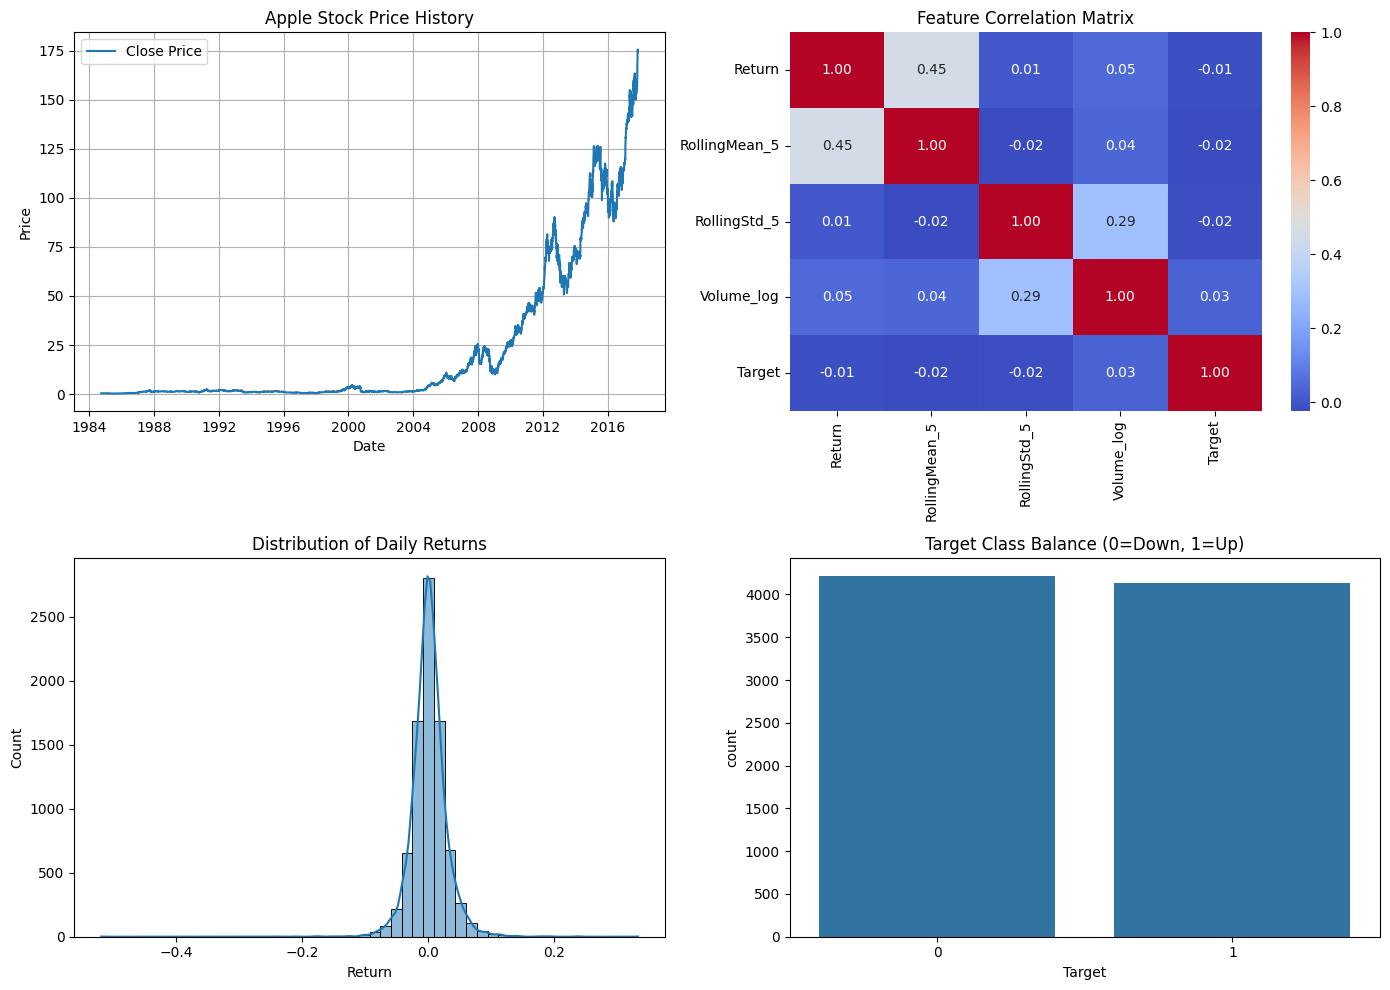

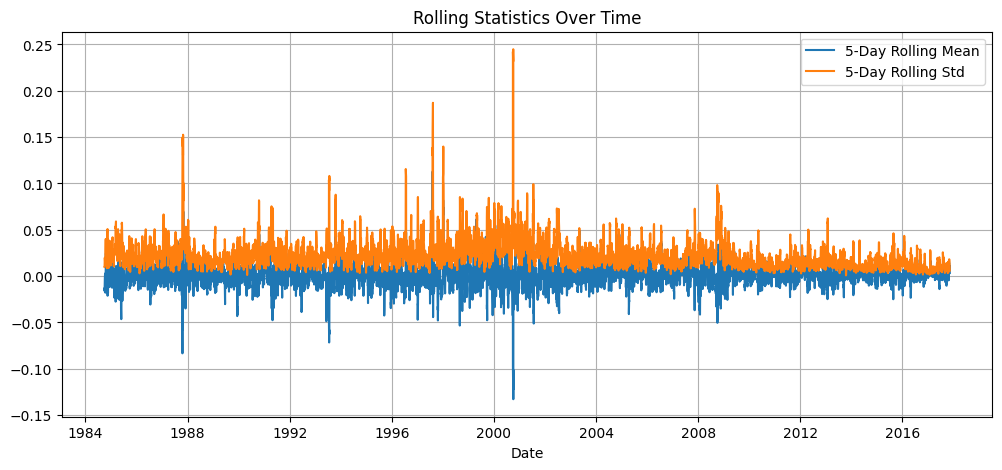

In [ ]:
# Data Visualization
plt.figure(figsize=(14, 10))

# Price History
plt.subplot(2, 2, 1)
plt.plot(pd.to_datetime(df['Date']), df['Close'], label='Close Price')
plt.title('Apple Stock Price History')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

# Feature Correlations
plt.subplot(2, 2, 2)
features_to_corr = ['Return', 'RollingMean_5', 'RollingStd_5', 'Volume_log', 'Target']
sns.heatmap(df[features_to_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')

# Return Distribution
plt.subplot(2, 2, 3)
sns.histplot(df['Return'], bins=50, kde=True)
plt.title('Distribution of Daily Returns')

# Target Balance
plt.subplot(2, 2, 4)
sns.countplot(x=df['Target'])
plt.title('Target Class Balance (0=Down, 1=Up)')

plt.tight_layout()
plt.show()


plt.figure(figsize=(12,5))
plt.plot(pd.to_datetime(df['Date']), df['RollingMean_5'], label='5-Day Rolling Mean')
plt.plot(pd.to_datetime(df['Date']), df['RollingStd_5'], label='5-Day Rolling Std')
plt.title('Rolling Statistics Over Time')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

The basic Exploratory Data Analysis (EDA) of the Apple stock data provides key insights into its distribution and temporal dynamics. Examining the distribution of daily returns reveals a concentration around zero, indicative of frequent small price fluctuations, alongside heavier tails that signal the occurrence of more significant positive or negative movements. The target class balance, which categorizes next-day returns as either positive or not, shows a relatively even split, with a slight predominance of 'down' movements. This balance is crucial for model training, as it mitigates bias stemming from imbalanced classes.

Analyzing the time series data, the Apple stock price history illustrates a consistent upward trend over the long term, punctuated by periods of heightened volatility. The rolling statistics, specifically the 5-day rolling mean and standard deviation of returns, offer a granular view of short-term behavior. The rolling mean of returns hovers around zero, reflecting the ephemeral nature of average daily changes, while the rolling standard deviation clearly highlights periods of increased market instability. Peaks in the standard deviation indicate times when the stock's price movements were more erratic over a five-day window. Furthermore, the feature correlation matrix helps to quantify the relationships between these engineered features and the target variable, showing how lagged and rolling metrics could influence future price movements.

## Part 1: Implementing RNN using TensorFlow

For Part 1, we implement a Recurrent Neural Network (RNN) using TensorFlow/Keras to model sequential Apple stock data. The network takes as input sequences of 25 consecutive days, where each time step contains multiple engineered features (returns, lagged returns, rolling statistics, and log-transformed volume).

The architecture consists of two stacked vanilla RNN (SimpleRNN) layers. The first RNN layer contains 32 hidden units and returns the full sequence to allow deeper temporal processing. The second RNN layer contains 16 hidden units and outputs the final hidden state. Both RNN layers use the tanh activation function at each time step, which is standard for vanilla RNNs and helps model nonlinear temporal relationships. Dropout regularization (0.2) is applied to reduce overfitting.

The final layer is a Dense layer with a sigmoid activation function, which outputs a probability representing whether the next-day return will be positive (binary classification). The model is trained using the Adam optimizer with binary cross-entropy loss, and class weights are incorporated to address potential class imbalance.

To evaluate performance, we use the F1 score, which balances precision and recall and is appropriate for potentially imbalanced classification problems. Rather than using a fixed 0.5 threshold, we tune the classification threshold on the validation set by selecting the value that maximizes the F1 score using the precision-recall curve. The optimized threshold is then applied to both the validation and test sets. Performance is reported on both sets to assess generalization.

In [ ]:
from sklearn.metrics import precision_recall_curve

# Build the Basic RNN Model
n_features = X_train.shape[2]

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(SEQ_LENGTH, n_features)),
    tf.keras.layers.SimpleRNN(32, activation='tanh', return_sequences=True, dropout=0.2),
    tf.keras.layers.SimpleRNN(16, activation='tanh', dropout=0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy')

# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the Model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate Using F1 Score with Threshold Tuning
y_val_probs = model.predict(X_val)
y_test_probs = model.predict(X_test)
y_val_probs = y_val_probs.ravel()
y_test_probs = y_test_probs.ravel()

# Find optimal threshold maximizing F1 on validation set
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_probs)

# Calculate F1 for each threshold (avoid division by zero)
with np.errstate(divide='ignore', invalid='ignore'):
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
f1_scores = np.nan_to_num(f1_scores)

# Ignore last element as it corresponds to probability 1.0
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
print(f"\nOptimal Threshold: {best_threshold:.4f}")

# Apply threshold
y_val_pred = (y_val_probs > best_threshold).astype(int)
y_test_pred = (y_test_probs > best_threshold).astype(int)

val_f1 = f1_score(y_val, y_val_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Validation F1 Score: {val_f1:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print(f"Unique predictions in test: {np.unique(y_test_pred, return_counts=True)}")

Epoch 1/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.7479 - val_loss: 0.7063
Epoch 2/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7050 - val_loss: 0.6964
Epoch 3/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7038 - val_loss: 0.6960
Epoch 4/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6957 - val_loss: 0.6969
Epoch 5/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6915 - val_loss: 0.6952
Epoch 6/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6926 - val_loss: 0.6942
Epoch 7/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6935 - val_loss: 0.6959
Epoch 8/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6909 - val_loss: 0.6971
Epoch 9/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6912 - val_loss: 0.6958
Epoch 10/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6934 - val_loss: 0.6959
Epoch 11/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6893 - val_loss: 0.6935
Epoch 12/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

### Training vs Validation Loss Curve for Basic RNN

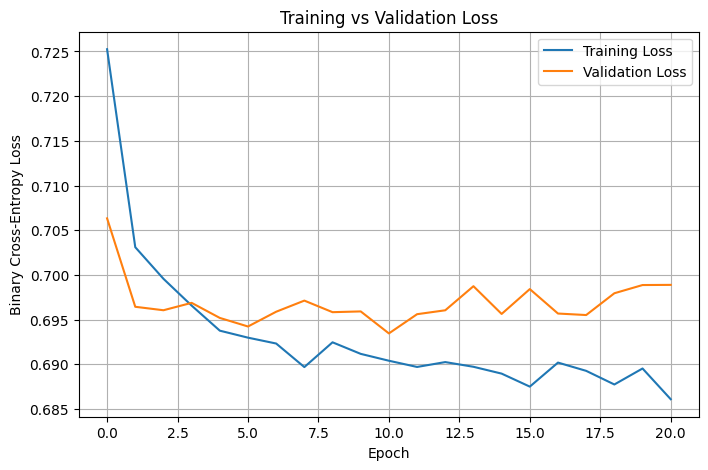

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)

plt.show()

## Part 2: LSTM and GRU based models

We update our previous network to first use and LSTM and then a GRU based cell structure, doing 2 separate implementations, comparing training and performance evaluation.

### LSTM Model

For Part 2, we replace the vanilla RNN with a Long Short-Term Memory (LSTM) network to better capture longer-term temporal dependencies in the stock return sequences. The model consists of two stacked LSTM layers. The first LSTM layer contains 32 memory units and returns the full sequence to allow deeper temporal feature extraction. The second LSTM layer contains 16 memory units and outputs the final hidden state representation. Both layers incorporate dropout regularization (0.2) to reduce overfitting.

Unlike a basic RNN, the LSTM architecture includes internal gating mechanisms (input, forget, and output gates) that control the flow of information through time, helping mitigate vanishing gradient issues and enabling the model to retain relevant information over longer horizons.

The final layer is a Dense layer with a sigmoid activation function, which outputs the probability that the next-day return will be positive. The model is trained using the Adam optimizer with binary cross-entropy loss, and class weights are applied to address class imbalance. As with the vanilla RNN, model performance is evaluated using the F1 score. The classification threshold is tuned on the validation set using the precision-recall curve to maximize F1, and the optimized threshold is then applied to both validation and test sets to assess generalization.

In [ ]:
# LSTM Model
lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(SEQ_LENGTH, n_features)),
    tf.keras.layers.LSTM(32, return_sequences=True, dropout=0.2),
    tf.keras.layers.LSTM(16, dropout=0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy')

# Train LSTM
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

# Evaluate LSTM with Threshold Tuning
y_val_probs_lstm = lstm_model.predict(X_val)
y_test_probs_lstm = lstm_model.predict(X_test)
y_val_probs_lstm = y_val_probs.ravel()
y_test_probs_lstm = y_test_probs.ravel()

precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_probs_lstm)
with np.errstate(divide='ignore', invalid='ignore'):
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
f1_scores = np.nan_to_num(f1_scores)
best_threshold_lstm = thresholds[np.argmax(f1_scores[:-1])]

print(f"LSTM Optimal Threshold: {best_threshold_lstm:.4f}")

y_val_pred_lstm = (y_val_probs_lstm > best_threshold_lstm).astype(int)
y_test_pred_lstm = (y_test_probs_lstm > best_threshold_lstm).astype(int)

val_f1_lstm = f1_score(y_val, y_val_pred_lstm)
test_f1_lstm = f1_score(y_test, y_test_pred_lstm)
print(f"LSTM Validation F1 Score: {val_f1_lstm:.4f}")
print(f"LSTM Test F1 Score: {test_f1_lstm:.4f}")

Epoch 1/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.6905 - val_loss: 0.6921
Epoch 2/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6914 - val_loss: 0.6911
Epoch 3/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6905 - val_loss: 0.6909
Epoch 4/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6903 - val_loss: 0.6910
Epoch 5/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6908 - val_loss: 0.6914
Epoch 6/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6901 - val_loss: 0.6909
Epoch 7/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6889 - val_loss: 0.6910
Epoch 8/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6872 - val_loss: 0.6914
Epoch 9/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6904 - val_loss: 0.6905
Epoch 10/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6908 - val_loss: 0.6903
Epoch 11/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6895 - val_loss: 0.6909
Epoch 12/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

### Training vs Validation Loss Curve for LSTM Model

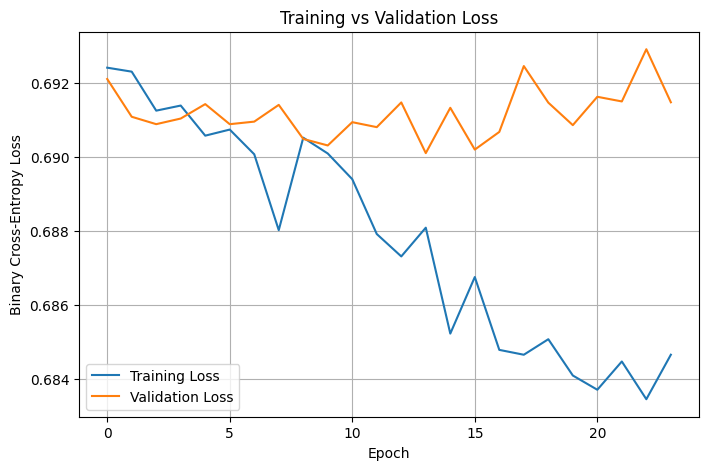

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(lstm_history.history['loss'], label='Training Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)

plt.show()

## GRU Model

For the final implementation, we replace the LSTM architecture with a Gated Recurrent Unit (GRU) network. The model consists of two stacked GRU layers. The first GRU layer contains 32 hidden units and returns the full sequence to allow hierarchical temporal feature learning. The second GRU layer contains 16 hidden units and outputs the final hidden state representation. Dropout regularization (0.2) is applied to both layers to reduce overfitting.

The GRU architecture is similar to the LSTM but uses a simplified gating mechanism consisting of update and reset gates. These gates regulate how much past information is retained and how much new information is incorporated at each time step. Compared to LSTMs, GRUs have fewer parameters, making them computationally more efficient while still effectively addressing the vanishing gradient problem seen in vanilla RNNs.

The final layer is a Dense layer with a sigmoid activation function that outputs the probability of a positive next-day return. The model is trained using the Adam optimizer with binary cross-entropy loss, and class weights are used to account for class imbalance. As with the previous models, the F1 score is used as the primary evaluation metric. The classification threshold is optimized on the validation set using the precision-recall curve to maximize the F1 score, and the selected threshold is then applied to both the validation and test sets to evaluate generalization performance.

In [ ]:
# GRU Model
gru_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(SEQ_LENGTH, n_features)),
    tf.keras.layers.GRU(32, return_sequences=True, dropout=0.2),
    tf.keras.layers.GRU(16, dropout=0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy')

# Train GRU
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

# Evaluate GRU with Threshold Tuning
y_val_probs_gru = gru_model.predict(X_val)
y_test_probs_gru = gru_model.predict(X_test)
y_val_probs_gru = y_val_probs.ravel()
y_test_probs_gru = y_test_probs.ravel()

precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_probs_gru)
with np.errstate(divide='ignore', invalid='ignore'):
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
f1_scores = np.nan_to_num(f1_scores)
best_threshold_gru = thresholds[np.argmax(f1_scores[:-1])]

print(f"GRU Optimal Threshold: {best_threshold_gru:.4f}")

y_val_pred_gru = (y_val_probs_gru > best_threshold_gru).astype(int)
y_test_pred_gru = (y_test_probs_gru > best_threshold_gru).astype(int)

val_f1_gru = f1_score(y_val, y_val_pred_gru)
test_f1_gru = f1_score(y_test, y_test_pred_gru)
print(f"GRU Validation F1 Score: {val_f1_gru:.4f}")
print(f"GRU Test F1 Score: {test_f1_gru:.4f}")
print(f"GRU Unique predictions: {np.unique(y_test_pred_gru, return_counts=True)}")


Epoch 1/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.6993 - val_loss: 0.6909
Epoch 2/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6915 - val_loss: 0.6913
Epoch 3/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6917 - val_loss: 0.6914
Epoch 4/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6906 - val_loss: 0.6917
Epoch 5/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6908 - val_loss: 0.6912
Epoch 6/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6899 - val_loss: 0.6912
Epoch 7/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6880 - val_loss: 0.6917
Epoch 8/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6890 - val_loss: 0.6912
Epoch 9/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6869 - val_loss: 0.6911
Epoch 10/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6889 - val_loss: 0.6910
Epoch 11/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6883 - val_loss: 0.6911
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
40/40 ━━━━━━━

### Training vs Validation Loss Curve for GRU Model

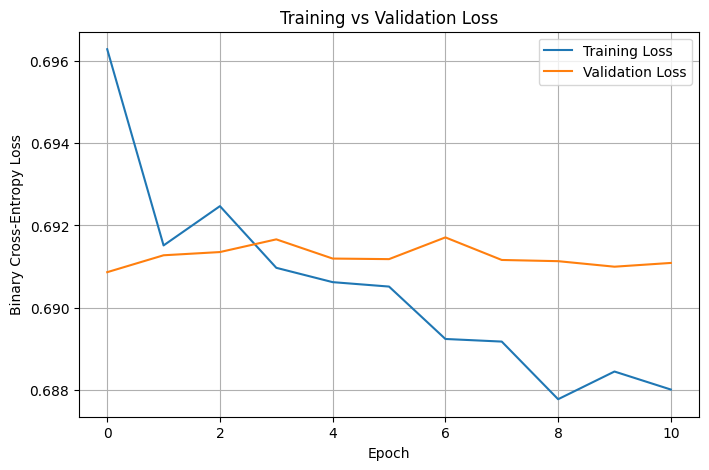

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(gru_history.history['loss'], label='Training Loss')
plt.plot(gru_history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)

plt.show()

### Model Performance Summary & Analysis
Across all three implementations (Basic RNN, LSTM, and GRU), the performance metrics were remarkably similar, reinforcing the difficulty of the prediction task on the stock market data.

The training versus validation loss plots for all three models tell show consistent underfitting or weak signal detection. In each case, the Training Loss shows a gradual but shallow decline, indicating that the models  struggled to learn patterns even from the training data. The Validation Loss curves are even more telling. They  plateau or oscillate around 0.69 almost immediately. There is no significant divergence between training and validation loss, which typically signals overfitting. Instead, the lack of significant reduction in either curve points to a lack of predictive signal in the input features.

The F1 scores on the test set were nearly identicalfor each model, ranging approximately between 0.68 and 0.69. Initially this seems like a decent result, but a closer look at the prediction counts reveals all three models largely collapsed to predicting the majority class (stock price going up). For example, the test set predictions were overwhelmingly dominated by the positive class (1), with very few negative predictions. This behavior suggests the models acted as "dummy classifiers," capitalizing on the slight upward trend of the market rather than learning distinct, short-term temporal reversal or continuation patterns.

Theoretically, one would expect the LSTM and GRU models to outperform the Basic RNN. The Basic RNN (SimpleRNN) suffers from the vanishing gradient problem, making it difficult to capture long-term dependencies in sequences. LSTMs and GRUs introduce gating mechanisms, specifically designed to retain relevant information over longer periods and mitigate gradient issues.

However, in this specific experiment, these theoretical advantages did not translate into empirical differences. The primary reasons likely include signal-to-noise ratio, sequence length, and feature set limitations. Daily stock returns are inherently noisy and often random. It is notoriously difficult to predict direction based solely on past price and simple rolling statistics. The lack of a strong, learnable signal meant that the superior architectural capabilities of LSTMs and GRUs had nothing "better" to learn than the Basic RNN.

## Part 3: Feed-Forward Neural Network (FFNN) Approach
A traditional feed-forward neural network (FFNN) can be applied to predicting the direction of Apple's daily stock returns, but only after converting the time series data into a suitable feature representation. In this case, we can use a sliding window of the past k days features, such as returns, rolling averages, rolling standard deviations, and volume — to create a fixed-length input vector for each day. This transforms the sequential stock data into a tabular format that a dense network can process.

While this allows an FFNN to make predictions, it does not explicitly model temporal dependencies between days. Recurrent architectures like RNNs, LSTMs, and GRUs maintain hidden states across time steps, which helps them capture patterns and trends in the stock data more naturally. As a result, FFNNs may struggle to learn meaningful temporal relationships, especially beyond the window length, whereas recurrent models are designed for sequential learning and can better handle long-term dependencies.

In summary, a feed-forward network could technically be used for this task by converting past stock features into a lagged input vector, but RNNs, LSTMs, and GRUs are generally more appropriate for modeling sequential stock data and capturing temporal dynamics.